# Q4 UdonPred Ensembles With ESMDisPred Context

Question: can ensembles of UdonPred's six retained dataset-specific heads outperform individual heads, and how should that local result be interpreted against ESMDisPred, a top CAID-family method?

This notebook evaluates UdonPred-only ensembles on the same retained local UdonPred test sets used earlier in the project. Learned weights and stacking models are fit only on validation predictions, then evaluated on held-out test predictions.

ESMDisPred is treated as external state-of-the-art context from CAID, not as a directly comparable number unless ESMDisPred predictions are generated on these same test FASTAs and scored with the same masks, label orientation, and metrics. CAID lists ESMDisPred variants among evaluated disorder predictors, and the CAID3 report emphasizes that many top-performing methods use protein language model embeddings.

References: [CAID methods](https://caid.idpcentral.org/methods), [CAID results](https://caid.idpcentral.org/challenge/results).

## 1. Setup

In [14]:
from __future__ import annotations

import json
import math
import os
import shlex
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.optimize import minimize
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.metrics import average_precision_score
from torchmetrics.functional import auroc, average_precision, spearman_corrcoef

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

UDONPRED_DIR = ROOT / "UdonPred"
ESMDISPRED_DIR = ROOT / "ESMDisPred"
RESULTS = ROOT / "results"
TEST_PREDICTION_ROOT = RESULTS / "udonpred_matrix" / "predictions"
VALID_PREDICTION_ROOT = RESULTS / "udonpred_validation_matrix" / "predictions"
ENSEMBLE_DIR = RESULTS / "ensembles"
ESMDISPRED_RESULT_ROOT = RESULTS / "esmdispred_matrix"
ESMDISPRED_PREDICTION_ROOT = ESMDISPRED_RESULT_ROOT / "predictions"
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["trizod", "chezod", "softdis", "atlas", "plddt", "disprot"]
ESMDISPRED_MODELS = ["ESMDisPred-1", "ESMDisPred-2", "ESMDisPred-2PDB", "ESMDisPred-DNN"]
NEGATED_DATASETS = {"chezod", "plddt"}
MASK_VALUE = 999.0
METRIC_COLS = [
    "trizod",
    "chezod",
    "softdis",
    "atlas",
    "plddt",
    "disprot\n(AP)",
    "disprot\n(AUROC)",
]

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

BATLOW_FALLBACK = [
    '#011959', '#0E3C67', '#1F6E6C', '#5C9D64',
    '#B7C75E', '#F7C95E', '#F06F45', '#B51F29',
]
try:
    from cmcrameri import cm as cmc
    BATLOW_CMAP = cmc.batlow
except ImportError:
    BATLOW_CMAP = LinearSegmentedColormap.from_list('batlow', BATLOW_FALLBACK)
BATLOW_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    'batlow_diverging', [BATLOW_FALLBACK[0], '#F6F1E7', BATLOW_FALLBACK[-1]]
)


def batlow_palette(n: int, *, reverse: bool = False):
    values = np.linspace(0.12, 0.88, n)
    if reverse:
        values = values[::-1]
    return [BATLOW_CMAP(value) for value in values]

## 2. Shared Helpers

The helpers below mirror the earlier notebooks: CheZOD and pLDDT are oriented so larger values mean more disorder, masked labels are excluded, continuous targets use Spearman correlation, and DisProt uses AP/AUROC.

In [15]:
def read_jsonl_records(path: Path) -> dict[str, dict[str, object]]:
    records = {}
    with path.open() as handle:
        for line in handle:
            raw = json.loads(line)
            records[str(raw["id"])] = {
                "sequence": str(raw["x_0"]),
                "labels": np.asarray(raw["y"], dtype=np.float64),
            }
    return records


def normalize_prediction_id(protein_id: str) -> str:
    protein_id = protein_id.strip().lstrip(">")
    if len(protein_id) >= 6 and protein_id.isdigit():
        base_len = len(protein_id) - 3
        return protein_id[:base_len] + "_" + "_".join(protein_id[base_len:])
    return protein_id


def read_caid_dir(input_dir: Path) -> dict[str, np.ndarray]:
    predictions = {}
    for path in sorted(input_dir.glob("*.caid")):
        with path.open() as handle:
            lines = handle.readlines()
        if not lines:
            raise ValueError(f"Empty prediction file: {path}")
        protein_id = normalize_prediction_id(lines[0])
        scores = []
        for line in lines[1:]:
            line = line.strip()
            if line:
                fields = line.split()
                if len(fields) < 3:
                    raise ValueError(f"Malformed CAID row in {path}: {line!r}")
                scores.append(float(fields[2]))
        predictions[protein_id] = np.asarray(scores, dtype=np.float64)
    return predictions


def count_fasta_records(path: Path) -> int:
    return sum(1 for line in path.read_text().splitlines() if line.startswith(">"))


def prediction_dir_complete(result_dir: Path, fasta_path: Path) -> bool:
    return result_dir.exists() and len(list(result_dir.glob("*.caid"))) == count_fasta_records(fasta_path)


def labels_in_disorder_direction(labels: np.ndarray, dataset: str) -> np.ndarray:
    return -labels if dataset in NEGATED_DATASETS else labels


def preds_in_disorder_direction(preds: np.ndarray, train_dataset: str) -> np.ndarray:
    return -preds if train_dataset in NEGATED_DATASETS else preds


def metric_columns_for_dataset(dataset: str) -> list[str]:
    if dataset == "disprot":
        return ["disprot\n(AP)", "disprot\n(AUROC)"]
    return [dataset]


def evaluate_vector(labels: np.ndarray, preds: np.ndarray, dataset: str) -> dict[str, float]:
    if len(labels) == 0:
        return {column: math.nan for column in metric_columns_for_dataset(dataset)}
    labels_tensor = torch.tensor(labels, dtype=torch.float32)
    preds_tensor = torch.tensor(preds, dtype=torch.float32)
    if dataset == "disprot":
        binary_labels = labels_tensor.to(torch.int)
        return {
            "disprot\n(AP)": float(average_precision(preds_tensor, binary_labels, task="binary")),
            "disprot\n(AUROC)": float(auroc(preds_tensor, binary_labels, task="binary")),
        }
    if np.unique(labels).size < 2 or np.unique(preds).size < 2:
        return {dataset: math.nan}
    return {dataset: float(spearman_corrcoef(preds_tensor, labels_tensor))}


def primary_metric(dataset: str) -> str:
    return "disprot\n(AP)" if dataset == "disprot" else dataset


def load_aligned_stack(split: str, prediction_root: Path, target_dataset: str) -> dict[str, object]:
    records = read_jsonl_records(UDONPRED_DIR / "data" / target_dataset / f"{split}.jsonl")
    pred_maps = {
        train_dataset: read_caid_dir(prediction_root / f"{train_dataset}_{target_dataset}")
        for train_dataset in DATASETS
    }

    label_chunks = []
    pred_chunks_by_train = {train_dataset: [] for train_dataset in DATASETS}
    residue_count = 0
    for protein_id, record in records.items():
        labels = np.asarray(record["labels"], dtype=np.float64)
        mask = np.isfinite(labels) & (labels != MASK_VALUE)
        if not np.any(mask):
            continue

        for train_dataset, pred_map in pred_maps.items():
            if protein_id not in pred_map:
                raise ValueError(f"Missing prediction for {protein_id} in {train_dataset}_{target_dataset}")
            preds = pred_map[protein_id]
            if len(preds) != len(labels):
                raise ValueError(
                    f"{train_dataset}_{target_dataset}/{protein_id}: prediction length {len(preds)} "
                    f"!= label length {len(labels)}"
                )
            pred_chunks_by_train[train_dataset].append(preds_in_disorder_direction(preds, train_dataset)[mask])

        label_chunks.append(labels_in_disorder_direction(labels, target_dataset)[mask])
        residue_count += int(mask.sum())

    y = np.concatenate(label_chunks)
    x = np.column_stack([np.concatenate(pred_chunks_by_train[train_dataset]) for train_dataset in DATASETS])
    return {"dataset": target_dataset, "split": split, "X": x, "y": y, "n_residues": residue_count}


def load_split_stacks(split: str, prediction_root: Path) -> dict[str, dict[str, object]]:
    return {
        target_dataset: load_aligned_stack(split, prediction_root, target_dataset)
        for target_dataset in DATASETS
    }


def load_aligned_external_predictions(
    split: str, prediction_dir: Path, target_dataset: str, predictor_name: str
) -> tuple[np.ndarray, np.ndarray, int]:
    """Load one external predictor's CAID files against a local labeled split.

    External predictors such as ESMDisPred already emit disorder probabilities, so
    their scores are not negated. Only labels are oriented to the project-wide
    convention that larger values mean more disorder.
    """
    records = read_jsonl_records(UDONPRED_DIR / "data" / target_dataset / f"{split}.jsonl")
    predictions = read_caid_dir(prediction_dir)

    label_chunks = []
    pred_chunks = []
    residue_count = 0
    for protein_id, record in records.items():
        labels = np.asarray(record["labels"], dtype=np.float64)
        mask = np.isfinite(labels) & (labels != MASK_VALUE)
        if not np.any(mask):
            continue
        if protein_id not in predictions:
            raise ValueError(f"Missing {predictor_name} prediction for {protein_id} in {prediction_dir}")
        preds = predictions[protein_id]
        if len(preds) != len(labels):
            raise ValueError(
                f"{predictor_name}/{target_dataset}/{protein_id}: prediction length {len(preds)} "
                f"!= label length {len(labels)}"
            )
        label_chunks.append(labels_in_disorder_direction(labels, target_dataset)[mask])
        pred_chunks.append(preds[mask])
        residue_count += int(mask.sum())

    return np.concatenate(label_chunks), np.concatenate(pred_chunks), residue_count


## 3. Generate Missing Validation Predictions

Learned ensembles must be fit on validation labels, not test labels. This cell creates the validation prediction matrix if it is missing. It skips complete prediction directories.

In [16]:
RUN_VALIDATION_PREDICTIONS = True

missing_validation_jobs = []
for train_dataset in DATASETS:
    for target_dataset in DATASETS:
        fasta_path = UDONPRED_DIR / "data" / target_dataset / "valid.fasta"
        result_dir = VALID_PREDICTION_ROOT / f"{train_dataset}_{target_dataset}"
        if not prediction_dir_complete(result_dir, fasta_path):
            missing_validation_jobs.append((train_dataset, target_dataset, fasta_path, result_dir))

print(f"Missing validation prediction jobs: {len(missing_validation_jobs)}")

if RUN_VALIDATION_PREDICTIONS:
    for train_dataset, target_dataset, fasta_path, result_dir in missing_validation_jobs:
        result_dir.mkdir(parents=True, exist_ok=True)
        cmd = [
            sys.executable,
            "predict.py",
            str(fasta_path),
            str(UDONPRED_DIR / "weights"),
            "--target",
            train_dataset,
            "--output",
            str(result_dir),
            "--device",
            "cuda",
            "--batch-size",
            "2000",
            "--smooth",
            "1.5",
        ]
        print("Running:", " ".join(cmd))
        subprocess.run(cmd, cwd=UDONPRED_DIR, check=True)
else:
    print("Set RUN_VALIDATION_PREDICTIONS = True to generate missing validation predictions.")

Missing validation prediction jobs: 0


## 4. Optional ESMDisPred Prediction Generation

ESMDisPred is one of the CAID-family top methods, but its published CAID performance is not directly comparable to the local UdonPred matrix. To make it comparable, generate ESMDisPred predictions on the same retained UdonPred test FASTAs and score them locally.

This generation path is disabled by default. It should remain disabled on this machine after the previous Windows/WSL watchdog crashes; existing local `.caid` outputs are still scored below. If ESMDisPred inference is run later in a stable environment, it should use pretrained models only, not retraining.

In [17]:
RUN_ESMDISPRED_PREDICTIONS = False  # disabled after repeated Windows/WSL watchdog crashes
ESMDISPRED_MODEL_OPTION = "ESMDisPred-DNN"
FORCE_ESMDISPRED_CPU = False  # set to True if GPU memory is insufficient for ESMDisPred-2; ESMDisPred-1 is much less memory-intensive
ESMDISPRED_ESM2_BATCH_SIZE = "1"  # conservative after WSL/Hyper-V 0x20001 crashes
ESMDISPRED_CACHE_DIR = ""  # empty: run_ESMDisPred.sh uses WSL ~/.cache/esmdispred


def path_for_bash(path: Path) -> str:
    """Convert local Path objects for the bash runner, including Windows -> WSL paths."""
    resolved = Path(path).resolve()
    if sys.platform != "win32":
        return str(resolved)
    drive = resolved.drive.rstrip(":").lower()
    parts = [part for part in resolved.parts[1:] if part]
    return "/mnt/" + drive + "/" + "/".join(parts)

missing_esmdispred_jobs = []
for target_dataset in DATASETS:
    fasta_path = UDONPRED_DIR / "data" / target_dataset / "test.fasta"
    output_dir = ESMDISPRED_PREDICTION_ROOT / target_dataset
    for model in ESMDISPRED_MODELS:
        result_dir = output_dir / "disorder" / model
        if not prediction_dir_complete(result_dir, fasta_path):
            missing_esmdispred_jobs.append((target_dataset, fasta_path, output_dir))
            break

print(f"Missing complete ESMDisPred test prediction jobs: {len(missing_esmdispred_jobs)}")
print(f"ESMDisPred environment present: {(ESMDISPRED_DIR / '.venv').exists()}")
print(f"ESMDisPred largeModels present: {(ESMDISPRED_DIR / 'largeModels').exists()}")

if RUN_ESMDISPRED_PREDICTIONS:
    if not (ESMDISPRED_DIR / ".venv").exists():
        raise FileNotFoundError("ESMDisPred/.venv is missing; run ESMDisPred/install_dependencies.sh first.")
    if not (ESMDISPRED_DIR / "largeModels").exists():
        raise FileNotFoundError("ESMDisPred/largeModels is missing; run ESMDisPred/run_downloadLargeModels.sh first.")

    seen = set()
    for target_dataset, fasta_path, output_dir in missing_esmdispred_jobs:
        if target_dataset in seen:
            continue
        seen.add(target_dataset)
        output_dir.mkdir(parents=True, exist_ok=True)
        cmd = [
            "bash",
            "run_ESMDisPred.sh",
            path_for_bash(fasta_path),
            path_for_bash(output_dir),
            ESMDISPRED_MODEL_OPTION,
        ]
        print("Running:", " ".join(cmd))
        env = os.environ.copy()
        env["ESMDISPRED_SAFE_MODE"] = "1"
        env["ESMDISPRED_FORCE_CPU"] = "1" if FORCE_ESMDISPRED_CPU else "0"
        env["ESMDISPRED_DEVICE"] = "cpu" if FORCE_ESMDISPRED_CPU else "auto"
        env["ESM2_BATCH_SIZE"] = ESMDISPRED_ESM2_BATCH_SIZE
        env.setdefault("OMP_NUM_THREADS", "1")
        env.setdefault("MKL_NUM_THREADS", "1")
        env.setdefault("OPENBLAS_NUM_THREADS", "1")
        env.setdefault("NUMEXPR_NUM_THREADS", "1")
        env.setdefault("ESMDISPRED_TORCH_THREADS", "1")
        if ESMDISPRED_CACHE_DIR:
            env["ESMDISPRED_CACHE_DIR"] = ESMDISPRED_CACHE_DIR
        if FORCE_ESMDISPRED_CPU:
            env["CUDA_VISIBLE_DEVICES"] = ""
        subprocess.run(cmd, cwd=ESMDISPRED_DIR, check=True, env=env)
else:
    print("ESMDisPred generation disabled. Existing local ESMDisPred .caid files will still be scored if present.")

Missing complete ESMDisPred test prediction jobs: 0
ESMDisPred environment present: True
ESMDisPred largeModels present: True
ESMDisPred generation disabled. Existing local ESMDisPred .caid files will still be scored if present.


## 5. Load And Sanity-Check Aligned Predictions

In [18]:
test_stacks = load_split_stacks("test", TEST_PREDICTION_ROOT)
valid_stacks = load_split_stacks("valid", VALID_PREDICTION_ROOT)

alignment_summary = pd.DataFrame(
    [
        {"split": "test", "dataset": dataset, "n_residues": stack["n_residues"], "n_heads": stack["X"].shape[1]}
        for dataset, stack in test_stacks.items()
    ]
    + [
        {"split": "valid", "dataset": dataset, "n_residues": stack["n_residues"], "n_heads": stack["X"].shape[1]}
        for dataset, stack in valid_stacks.items()
    ]
)
display(alignment_summary)

,split,dataset,n_residues,n_heads
0,test,trizod,37133,6
1,test,chezod,13068,6
2,test,softdis,271668,6
3,test,atlas,16907,6
4,test,plddt,62945,6
5,test,disprot,99239,6
6,valid,trizod,77160,6
7,valid,chezod,13334,6
8,valid,softdis,424887,6
9,valid,atlas,34783,6


## 6. Optional Local ESMDisPred Evaluation

If ESMDisPred `.caid` outputs are available under `results/esmdispred_matrix/predictions/<dataset>/disorder/<model>/`, this cell scores every complete local model/dataset pair against the same held-out test labels used for UdonPred. A complete retained-dataset matrix is reported only when all datasets are available; otherwise Q4 treats the full CAID comparison as context and uses partial local outputs only for clearly labeled diagnostics.

In [19]:
def esmdispred_prediction_dir(model: str, target_dataset: str) -> Path:
    return ESMDISPRED_PREDICTION_ROOT / target_dataset / "disorder" / model


esmdispred_rows = []
esmdispred_available_rows = []
esmdispred_coverage_rows = []
for model in ESMDISPRED_MODELS:
    row = {"method": model}
    complete_model = True
    for target_dataset in DATASETS:
        fasta_path = UDONPRED_DIR / "data" / target_dataset / "test.fasta"
        pred_dir = esmdispred_prediction_dir(model, target_dataset)
        expected_files = count_fasta_records(fasta_path)
        observed_files = len(list(pred_dir.glob("*.caid"))) if pred_dir.exists() else 0
        is_complete = observed_files == expected_files
        esmdispred_coverage_rows.append(
            {
                "method": model,
                "target_dataset": target_dataset,
                "expected_files": expected_files,
                "observed_files": observed_files,
                "complete": is_complete,
                "prediction_dir": str(pred_dir),
            }
        )
        if not is_complete:
            complete_model = False
            continue

        labels, preds, _ = load_aligned_external_predictions("test", pred_dir, target_dataset, model)
        metrics = evaluate_vector(labels, preds, target_dataset)
        row.update(metrics)
        primary = primary_metric(target_dataset)
        esmdispred_available_rows.append(
            {
                "method": model,
                "target_dataset": target_dataset,
                "primary_metric": primary,
                "primary_score": metrics[primary],
                **metrics,
            }
        )
    if complete_model:
        esmdispred_rows.append(row)

ESMDISPRED_RESULT_ROOT.mkdir(parents=True, exist_ok=True)
esmdispred_coverage = pd.DataFrame(esmdispred_coverage_rows)
esmdispred_available_long = pd.DataFrame(esmdispred_available_rows)
esmdispred_coverage.to_csv(ESMDISPRED_RESULT_ROOT / "local_coverage.csv", index=False)
if not esmdispred_available_long.empty:
    esmdispred_available_long.to_csv(ESMDISPRED_RESULT_ROOT / "local_available_long.csv", index=False)

if esmdispred_rows:
    esmdispred_matrix = pd.DataFrame(esmdispred_rows).set_index("method")[METRIC_COLS]
    esmdispred_matrix.to_csv(ESMDISPRED_RESULT_ROOT / "local_matrix.csv")
    display(esmdispred_matrix.style.format("{:.3f}"))
else:
    esmdispred_matrix = pd.DataFrame(columns=METRIC_COLS)
    print("No complete retained-dataset local ESMDisPred matrix found; full CAID comparison remains context only.")

if not esmdispred_available_long.empty:
    if esmdispred_matrix.empty:
        print("Partial local ESMDisPred scores found; these are diagnostics, not a complete all-dataset matrix.")
    else:
        print("Local ESMDisPred scores found for at least one complete retained-dataset model.")
    display(
        esmdispred_available_long[
            ["method", "target_dataset", "primary_metric", "primary_score"]
        ].sort_values(["method", "target_dataset"]).style.format({"primary_score": "{:.3f}"})
    )
else:
    print("No local ESMDisPred scores found; ESMDisPred remains external CAID context for this Q4 run.")

display(esmdispred_coverage.query("complete == False").head(12))


,trizod,chezod,softdis,atlas,plddt,disprot (AP),disprot (AUROC)
method,,,,,,,
ESMDisPred-1,0.271,0.481,0.158,0.428,0.533,0.752,0.861
ESMDisPred-2,0.338,0.523,0.223,0.523,0.624,0.856,0.913
ESMDisPred-2PDB,0.342,0.548,0.245,0.554,0.671,0.886,0.934
ESMDisPred-DNN,0.329,0.608,0.232,0.492,0.697,0.902,0.943


Local ESMDisPred scores found for at least one complete retained-dataset model.


,method,target_dataset,primary_metric,primary_score
3,ESMDisPred-1,atlas,atlas,0.428
1,ESMDisPred-1,chezod,chezod,0.481
5,ESMDisPred-1,disprot,disprot (AP),0.752
4,ESMDisPred-1,plddt,plddt,0.533
2,ESMDisPred-1,softdis,softdis,0.158
0,ESMDisPred-1,trizod,trizod,0.271
9,ESMDisPred-2,atlas,atlas,0.523
7,ESMDisPred-2,chezod,chezod,0.523
11,ESMDisPred-2,disprot,disprot (AP),0.856
10,ESMDisPred-2,plddt,plddt,0.624


,method,target_dataset,expected_files,observed_files,complete,prediction_dir


In [20]:
def score_individual_heads(stacks: dict[str, dict[str, object]]) -> pd.DataFrame:
    rows = []
    for train_index, train_dataset in enumerate(DATASETS):
        row = {"train_dataset": train_dataset}
        for target_dataset, stack in stacks.items():
            row.update(evaluate_vector(stack["y"], stack["X"][:, train_index], target_dataset))
        rows.append(row)
    return pd.DataFrame(rows).set_index("train_dataset")[METRIC_COLS]


recomputed_individual = score_individual_heads(test_stacks)
published_individual = pd.read_csv(RESULTS / "udonpred_matrix" / "matrix.csv").set_index("train_dataset")[METRIC_COLS]
published_individual = published_individual.apply(pd.to_numeric)

max_abs_delta = (recomputed_individual - published_individual).abs().max().max()
print(f"Max absolute delta versus results/udonpred_matrix/matrix.csv: {max_abs_delta:.6f}")
if max_abs_delta > 5e-4:
    raise ValueError("Recomputed individual-head matrix does not match the saved UdonPred matrix.")

best_individual_scores = recomputed_individual.max(axis=0)
best_individual_heads = recomputed_individual.idxmax(axis=0)
display(recomputed_individual.style.format("{:.3f}"))

Max absolute delta versus results/udonpred_matrix/matrix.csv: 0.000016


,trizod,chezod,softdis,atlas,plddt,disprot (AP),disprot (AUROC)
train_dataset,,,,,,,
trizod,0.508,0.708,0.257,0.413,0.719,0.899,0.930
chezod,0.486,0.691,0.235,0.327,0.713,0.890,0.925
softdis,0.470,0.537,0.500,0.597,0.784,0.872,0.918
atlas,0.400,0.595,0.310,0.708,0.719,0.870,0.920
plddt,0.423,0.625,0.284,0.512,0.839,0.875,0.927
disprot,0.364,0.663,0.255,0.624,0.774,0.935,0.959


## 7. Fit Non-Leaky Ensembles On Validation Data

In [21]:
def concatenate_stacks(stacks: list[dict[str, object]]) -> tuple[np.ndarray, np.ndarray]:
    x = np.vstack([stack["X"] for stack in stacks])
    y = np.concatenate([stack["y"] for stack in stacks])
    return x, y


def fit_convex_weights(stacks: list[dict[str, object]]) -> np.ndarray:
    x, y = concatenate_stacks(stacks)
    n_heads = x.shape[1]
    start = np.full(n_heads, 1.0 / n_heads)
    constraints = ({"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0)},)
    bounds = [(0.0, 1.0)] * n_heads

    def objective(weights: np.ndarray) -> float:
        residual = x @ weights - y
        return float(np.mean(residual * residual))

    result = minimize(objective, start, method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        raise RuntimeError(f"Convex-weight optimization failed: {result.message}")
    weights = np.asarray(result.x, dtype=np.float64)
    weights[weights < 1e-10] = 0.0
    return weights / weights.sum()


def fit_ridge_model(stacks: list[dict[str, object]], alpha: float = 1.0) -> Ridge:
    x, y = concatenate_stacks(stacks)
    model = Ridge(alpha=alpha)
    model.fit(x, y)
    return model


valid_individual = score_individual_heads(valid_stacks)
selected_head_by_target = {
    dataset: valid_individual[primary_metric(dataset)].idxmax()
    for dataset in DATASETS
}

global_convex_weights = fit_convex_weights([valid_stacks[dataset] for dataset in DATASETS])
per_target_convex_weights = {
    dataset: fit_convex_weights([valid_stacks[dataset]])
    for dataset in DATASETS
}

global_ridge = fit_ridge_model([valid_stacks[dataset] for dataset in DATASETS])
per_target_ridge = {
    dataset: fit_ridge_model([valid_stacks[dataset]])
    for dataset in DATASETS
}

weight_rows = [
    {"strategy": "global_convex_validation", "target_dataset": "all", **dict(zip(DATASETS, global_convex_weights))}
]
weight_rows += [
    {"strategy": "per_target_convex_validation", "target_dataset": dataset, **dict(zip(DATASETS, weights))}
    for dataset, weights in per_target_convex_weights.items()
]
weights_df = pd.DataFrame(weight_rows)
weights_df.to_csv(ENSEMBLE_DIR / "ensemble_weights.csv", index=False)

print("Validation-selected head by target:")
display(pd.Series(selected_head_by_target, name="selected_train_dataset").to_frame())
display(weights_df.style.format({dataset: "{:.3f}" for dataset in DATASETS}))

Validation-selected head by target:


,selected_train_dataset
trizod,trizod
chezod,chezod
softdis,softdis
atlas,atlas
plddt,plddt
disprot,disprot


,strategy,target_dataset,trizod,chezod,softdis,atlas,plddt,disprot
0,global_convex_validation,all,0.869,0.000,0.000,0.000,0.131,0.000
1,per_target_convex_validation,trizod,0.939,0.000,0.016,0.001,0.000,0.044
2,per_target_convex_validation,chezod,0.000,1.000,0.000,0.000,0.000,0.000
3,per_target_convex_validation,softdis,0.000,0.000,1.000,0.000,0.000,0.000
4,per_target_convex_validation,atlas,0.000,0.000,0.000,1.000,0.000,0.000
5,per_target_convex_validation,plddt,0.000,0.000,0.000,0.000,1.000,0.000
6,per_target_convex_validation,disprot,0.000,0.001,0.000,0.000,0.000,0.999


## 8. Evaluate Ensemble Strategies On Test Sets

In [22]:
def strategy_predictions_for_dataset(strategy: str, dataset: str, stack: dict[str, object]) -> np.ndarray:
    x = stack["X"]
    if strategy == "simple_mean_all_heads":
        return x.mean(axis=1)
    if strategy == "validation_selected_single_head":
        return x[:, DATASETS.index(selected_head_by_target[dataset])]
    if strategy == "global_convex_validation":
        return x @ global_convex_weights
    if strategy == "per_target_convex_validation":
        return x @ per_target_convex_weights[dataset]
    if strategy == "global_ridge_stacking_validation":
        return global_ridge.predict(x)
    if strategy == "per_target_ridge_stacking_validation":
        return per_target_ridge[dataset].predict(x)
    raise ValueError(f"Unknown strategy: {strategy}")


strategies = [
    "best_individual_test_oracle",
    "simple_mean_all_heads",
    "validation_selected_single_head",
    "global_convex_validation",
    "per_target_convex_validation",
    "global_ridge_stacking_validation",
    "per_target_ridge_stacking_validation",
]

rows = []
for strategy in strategies:
    row = {"strategy": strategy}
    if strategy == "best_individual_test_oracle":
        row.update(best_individual_scores.to_dict())
    else:
        for dataset, stack in test_stacks.items():
            preds = strategy_predictions_for_dataset(strategy, dataset, stack)
            row.update(evaluate_vector(stack["y"], preds, dataset))
    rows.append(row)

ensemble_matrix = pd.DataFrame(rows).set_index("strategy")[METRIC_COLS]
ensemble_delta = ensemble_matrix.subtract(best_individual_scores, axis="columns")

summary_rows = []
for strategy in ensemble_matrix.index:
    deltas = ensemble_delta.loc[strategy]
    summary_rows.append(
        {
            "strategy": strategy,
            "mean_score": float(ensemble_matrix.loc[strategy].mean()),
            "mean_delta_vs_best_individual": float(deltas.mean()),
            "wins_vs_best_individual": int((deltas > 1e-6).sum()),
            "ties_vs_best_individual": int((deltas.abs() <= 1e-6).sum()),
            "losses_vs_best_individual": int((deltas < -1e-6).sum()),
            "best_delta": float(deltas.max()),
            "worst_delta": float(deltas.min()),
        }
    )
ensemble_summary = pd.DataFrame(summary_rows).set_index("strategy")

ensemble_matrix.to_csv(ENSEMBLE_DIR / "ensemble_matrix.csv")
ensemble_delta.to_csv(ENSEMBLE_DIR / "ensemble_delta_vs_best_individual.csv")
ensemble_summary.to_csv(ENSEMBLE_DIR / "ensemble_summary.csv")
valid_individual.to_csv(ENSEMBLE_DIR / "validation_individual_matrix.csv")

display(ensemble_matrix.style.format("{:.3f}"))
display(ensemble_delta.style.format("{:+.3f}"))
display(ensemble_summary.style.format("{:.3f}"))

,trizod,chezod,softdis,atlas,plddt,disprot (AP),disprot (AUROC)
strategy,,,,,,,
best_individual_test_oracle,0.508,0.708,0.500,0.708,0.839,0.935,0.959
simple_mean_all_heads,0.452,0.651,0.304,0.528,0.835,0.893,0.937
validation_selected_single_head,0.508,0.691,0.500,0.708,0.839,0.935,0.959
global_convex_validation,0.430,0.637,0.287,0.519,0.839,0.885,0.933
per_target_convex_validation,0.505,0.691,0.500,0.708,0.839,0.936,0.959
global_ridge_stacking_validation,-0.432,-0.668,-0.143,-0.028,-0.384,0.222,0.217
per_target_ridge_stacking_validation,0.503,0.702,0.507,0.660,0.846,0.932,0.954


,trizod,chezod,softdis,atlas,plddt,disprot (AP),disprot (AUROC)
strategy,,,,,,,
best_individual_test_oracle,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000
simple_mean_all_heads,-0.055,-0.057,-0.196,-0.180,-0.004,-0.042,-0.022
validation_selected_single_head,+0.000,-0.017,+0.000,+0.000,+0.000,+0.000,+0.000
global_convex_validation,-0.077,-0.070,-0.213,-0.189,+0.000,-0.050,-0.026
per_target_convex_validation,-0.003,-0.017,+0.000,+0.000,+0.000,+0.000,+0.000
global_ridge_stacking_validation,-0.940,-1.376,-0.643,-0.736,-1.223,-0.713,-0.742
per_target_ridge_stacking_validation,-0.004,-0.006,+0.007,-0.048,+0.007,-0.003,-0.004


,mean_score,mean_delta_vs_best_individual,wins_vs_best_individual,ties_vs_best_individual,losses_vs_best_individual,best_delta,worst_delta
strategy,,,,,,,
best_individual_test_oracle,0.737,0.000,0.000,7.000,0.000,0.000,0.000
simple_mean_all_heads,0.657,-0.080,0.000,0.000,7.000,-0.004,-0.196
validation_selected_single_head,0.734,-0.002,0.000,6.000,1.000,0.000,-0.017
global_convex_validation,0.647,-0.090,1.000,0.000,6.000,0.000,-0.213
per_target_convex_validation,0.734,-0.003,2.000,3.000,2.000,0.000,-0.017
global_ridge_stacking_validation,-0.174,-0.911,0.000,0.000,7.000,-0.643,-1.376
per_target_ridge_stacking_validation,0.729,-0.007,2.000,0.000,5.000,0.007,-0.048


## 9. External Predictor Combination Check

For every complete ESMDisPred variant and target dataset, this diagnostic compares the external predictor alone and a fixed 50/50 residue-level average with the best non-oracle UdonPred-only strategy. Because ESMDisPred validation predictions were not generated, no external stacking weights are learned.


In [23]:
external_comparison_rows = []
udon_non_oracle = ensemble_matrix.drop(index="best_individual_test_oracle")

for external_method in ESMDISPRED_MODELS:
    method_available = esmdispred_available_long[
        esmdispred_available_long["method"].eq(external_method)
    ] if not esmdispred_available_long.empty else pd.DataFrame()

    for _, ext_row in method_available.iterrows():
        target_dataset = ext_row["target_dataset"]
        metric = primary_metric(target_dataset)
        best_udon_strategy = udon_non_oracle[metric].idxmax()
        stack = test_stacks[target_dataset]
        labels, external_preds, _ = load_aligned_external_predictions(
            "test",
            esmdispred_prediction_dir(external_method, target_dataset),
            target_dataset,
            external_method,
        )
        if len(labels) != len(stack["y"]) or not np.allclose(labels, stack["y"]):
            raise ValueError(f"Label alignment mismatch for {external_method}/{target_dataset}")

        udon_preds = strategy_predictions_for_dataset(best_udon_strategy, target_dataset, stack)
        fixed_mean_preds = 0.5 * udon_preds + 0.5 * external_preds
        best_individual_score = float(best_individual_scores[metric])
        udon_score = evaluate_vector(stack["y"], udon_preds, target_dataset)[metric]
        external_score = evaluate_vector(labels, external_preds, target_dataset)[metric]
        fixed_mean_score = evaluate_vector(labels, fixed_mean_preds, target_dataset)[metric]
        external_comparison_rows.append(
            {
                "external_method": external_method,
                "target_dataset": target_dataset,
                "metric": metric,
                "best_udon_strategy": best_udon_strategy,
                "best_individual_udon": best_individual_score,
                "best_udon_ensemble": udon_score,
                "external_score": external_score,
                "fixed_mean_score": fixed_mean_score,
                "delta_fixed_mean_vs_udon_ensemble": fixed_mean_score - udon_score,
                "delta_fixed_mean_vs_best_individual": fixed_mean_score - best_individual_score,
            }
        )

external_comparison = pd.DataFrame(external_comparison_rows)
if not external_comparison.empty:
    external_comparison.to_csv(
        ESMDISPRED_RESULT_ROOT / "external_combination_all_models.csv",
        index=False,
    )
    display(
        external_comparison.sort_values(["external_method", "target_dataset"]).style.format(
            {
                "best_individual_udon": "{:.3f}",
                "best_udon_ensemble": "{:.3f}",
                "external_score": "{:.3f}",
                "fixed_mean_score": "{:.3f}",
                "delta_fixed_mean_vs_udon_ensemble": "{:+.3f}",
                "delta_fixed_mean_vs_best_individual": "{:+.3f}",
            }
        )
    )
else:
    print("No complete local ESMDisPred datasets available for the external combination check.")


,external_method,target_dataset,metric,best_udon_strategy,best_individual_udon,best_udon_ensemble,external_score,fixed_mean_score,delta_fixed_mean_vs_udon_ensemble,delta_fixed_mean_vs_best_individual
3,ESMDisPred-1,atlas,atlas,validation_selected_single_head,0.708,0.708,0.428,0.658,-0.050,-0.050
1,ESMDisPred-1,chezod,chezod,per_target_ridge_stacking_validation,0.708,0.702,0.481,0.701,-0.001,-0.007
5,ESMDisPred-1,disprot,disprot (AP),per_target_convex_validation,0.935,0.936,0.752,0.923,-0.013,-0.012
4,ESMDisPred-1,plddt,plddt,per_target_ridge_stacking_validation,0.839,0.846,0.533,0.846,+0.001,+0.008
2,ESMDisPred-1,softdis,softdis,per_target_ridge_stacking_validation,0.500,0.507,0.158,0.418,-0.090,-0.082
0,ESMDisPred-1,trizod,trizod,validation_selected_single_head,0.508,0.508,0.271,0.384,-0.124,-0.124
9,ESMDisPred-2,atlas,atlas,validation_selected_single_head,0.708,0.708,0.523,0.688,-0.020,-0.020
7,ESMDisPred-2,chezod,chezod,per_target_ridge_stacking_validation,0.708,0.702,0.523,0.701,-0.001,-0.007
11,ESMDisPred-2,disprot,disprot (AP),per_target_convex_validation,0.935,0.936,0.856,0.933,-0.002,-0.002
10,ESMDisPred-2,plddt,plddt,per_target_ridge_stacking_validation,0.839,0.846,0.624,0.846,+0.000,+0.007


## 10. Why Do ESMDisPred And UdonPred Differ?

This section investigates whether the performance gap is associated with target type, predictor agreement, output spread, or protein-level consistency. Aggregate diagnostics use every masked residue. To keep the large test sets tractable, per-protein score distributions use up to 150 evenly selected proteins per dataset and exclude proteins whose labels or predictions do not vary enough for the relevant metric.


In [24]:
def safe_spearman(left: np.ndarray, right: np.ndarray) -> float:
    if len(left) < 2 or np.unique(left).size < 2 or np.unique(right).size < 2:
        return math.nan
    return float(spearmanr(left, right).statistic)


def safe_primary_score(labels: np.ndarray, preds: np.ndarray, dataset: str) -> float:
    if len(labels) < 2 or np.unique(labels).size < 2 or np.unique(preds).size < 2:
        return math.nan
    if dataset == "disprot":
        return float(average_precision_score(labels.astype(int), preds))
    return safe_spearman(labels, preds)


PER_PROTEIN_SAMPLE_SIZE = 150

dataset_diagnostic_rows = []
model_diagnostic_rows = []
protein_diagnostic_rows = []

for target_dataset in DATASETS:
    metric = primary_metric(target_dataset)
    best_udon_strategy = udon_non_oracle[metric].idxmax()
    records = read_jsonl_records(UDONPRED_DIR / "data" / target_dataset / "test.jsonl")
    udon_pred_maps = {
        train_dataset: read_caid_dir(TEST_PREDICTION_ROOT / f"{train_dataset}_{target_dataset}")
        for train_dataset in DATASETS
    }

    protein_base = {}
    sequence_lengths = []
    all_labels = []
    all_udon_preds = []
    for protein_id, record in records.items():
        labels_raw = np.asarray(record["labels"], dtype=np.float64)
        mask = np.isfinite(labels_raw) & (labels_raw != MASK_VALUE)
        if not np.any(mask):
            continue

        head_chunks = []
        for train_dataset in DATASETS:
            if protein_id not in udon_pred_maps[train_dataset]:
                raise ValueError(f"Missing UdonPred prediction for {train_dataset}/{target_dataset}/{protein_id}")
            head_preds = udon_pred_maps[train_dataset][protein_id]
            if len(head_preds) != len(labels_raw):
                raise ValueError(
                    f"UdonPred/{train_dataset}/{target_dataset}/{protein_id}: "
                    f"prediction length {len(head_preds)} != label length {len(labels_raw)}"
                )
            head_chunks.append(preds_in_disorder_direction(head_preds, train_dataset)[mask])

        x_protein = np.column_stack(head_chunks)
        labels = labels_in_disorder_direction(labels_raw, target_dataset)[mask]
        udon_preds = strategy_predictions_for_dataset(
            best_udon_strategy,
            target_dataset,
            {"X": x_protein},
        )
        protein_base[protein_id] = {
            "labels": labels,
            "udon_preds": udon_preds,
            "mask": mask,
            "sequence_length": len(labels_raw),
        }
        sequence_lengths.append(len(labels_raw))
        all_labels.append(labels)
        all_udon_preds.append(udon_preds)

    labels_all = np.concatenate(all_labels)
    udon_all = np.concatenate(all_udon_preds)
    sorted_protein_ids = sorted(protein_base)
    if len(sorted_protein_ids) <= PER_PROTEIN_SAMPLE_SIZE:
        sampled_protein_ids = set(sorted_protein_ids)
    else:
        sample_indices = np.linspace(
            0,
            len(sorted_protein_ids) - 1,
            PER_PROTEIN_SAMPLE_SIZE,
            dtype=int,
        )
        sampled_protein_ids = {sorted_protein_ids[index] for index in sample_indices}
    for protein_id in sampled_protein_ids:
        base = protein_base[protein_id]
        base["udon_protein_score"] = safe_primary_score(
            base["labels"], base["udon_preds"], target_dataset
        )

    dataset_diagnostic_rows.append(
        {
            "target_dataset": target_dataset,
            "target_type": "binary disorder" if target_dataset == "disprot" else "continuous rank target",
            "primary_metric": metric,
            "n_proteins": len(protein_base),
            "n_sampled_proteins": len(sampled_protein_ids),
            "n_masked_residues": len(labels_all),
            "median_sequence_length": float(np.median(sequence_lengths)),
            "label_mean": float(np.mean(labels_all)),
            "label_std": float(np.std(labels_all)),
            "positive_fraction": float(np.mean(labels_all)) if target_dataset == "disprot" else math.nan,
            "best_udon_strategy": best_udon_strategy,
            "best_udon_score": float(udon_non_oracle.loc[best_udon_strategy, metric]),
            "udon_prediction_mean": float(np.mean(udon_all)),
            "udon_prediction_std": float(np.std(udon_all)),
        }
    )

    for external_method in ESMDISPRED_MODELS:
        external_map = read_caid_dir(esmdispred_prediction_dir(external_method, target_dataset))
        external_chunks = []
        fixed_mean_chunks = []
        valid_udon_scores = []
        valid_external_scores = []
        valid_fixed_scores = []

        for protein_id, base in protein_base.items():
            if protein_id not in external_map:
                raise ValueError(f"Missing {external_method} prediction for {target_dataset}/{protein_id}")
            external_raw = external_map[protein_id]
            if len(external_raw) != base["sequence_length"]:
                raise ValueError(
                    f"{external_method}/{target_dataset}/{protein_id}: "
                    f"prediction length {len(external_raw)} != sequence length {base['sequence_length']}"
                )

            external_preds = external_raw[base["mask"]]
            fixed_mean_preds = 0.5 * base["udon_preds"] + 0.5 * external_preds
            external_chunks.append(external_preds)
            fixed_mean_chunks.append(fixed_mean_preds)

            if protein_id in sampled_protein_ids:
                udon_protein_score = base["udon_protein_score"]
                external_protein_score = safe_primary_score(base["labels"], external_preds, target_dataset)
                fixed_protein_score = safe_primary_score(base["labels"], fixed_mean_preds, target_dataset)
                protein_diagnostic_rows.append(
                    {
                        "external_method": external_method,
                        "target_dataset": target_dataset,
                        "protein_id": protein_id,
                        "n_masked_residues": len(base["labels"]),
                        "udon_score": udon_protein_score,
                        "external_score": external_protein_score,
                        "fixed_mean_score": fixed_protein_score,
                        "external_delta_vs_udon": external_protein_score - udon_protein_score,
                        "fixed_mean_delta_vs_udon": fixed_protein_score - udon_protein_score,
                        "prediction_agreement": safe_spearman(base["udon_preds"], external_preds),
                    }
                )
                if np.isfinite(udon_protein_score) and np.isfinite(external_protein_score):
                    valid_udon_scores.append(udon_protein_score)
                    valid_external_scores.append(external_protein_score)
                if np.isfinite(udon_protein_score) and np.isfinite(fixed_protein_score):
                    valid_fixed_scores.append((udon_protein_score, fixed_protein_score))

        external_all = np.concatenate(external_chunks)
        fixed_mean_all = np.concatenate(fixed_mean_chunks)
        per_protein_delta = np.asarray(valid_external_scores) - np.asarray(valid_udon_scores)
        fixed_pairs = np.asarray(valid_fixed_scores)
        comparison_match = external_comparison[
            external_comparison["external_method"].eq(external_method)
            & external_comparison["target_dataset"].eq(target_dataset)
        ]
        if len(comparison_match) != 1:
            raise ValueError(
                f"Expected one aggregate comparison row for {external_method}/{target_dataset}; "
                f"found {len(comparison_match)}"
            )
        comparison_row = comparison_match.iloc[0]
        model_diagnostic_rows.append(
            {
                "external_method": external_method,
                "target_dataset": target_dataset,
                "primary_metric": metric,
                "udon_score": float(comparison_row["best_udon_ensemble"]),
                "external_score": float(comparison_row["external_score"]),
                "score_gap_external_minus_udon": float(comparison_row["external_score"])
                - float(comparison_row["best_udon_ensemble"]),
                "fixed_mean_score": float(comparison_row["fixed_mean_score"]),
                "fixed_mean_delta_vs_udon": float(comparison_row["delta_fixed_mean_vs_udon_ensemble"]),
                "prediction_agreement_spearman": safe_spearman(udon_all, external_all),
                "external_prediction_mean": float(np.mean(external_all)),
                "external_prediction_std": float(np.std(external_all)),
                "output_std_ratio_external_to_udon": float(np.std(external_all) / np.std(udon_all))
                if np.std(udon_all) > 0 else math.nan,
                "n_valid_proteins": len(per_protein_delta),
                "external_protein_win_rate": float(np.mean(per_protein_delta > 1e-6))
                if len(per_protein_delta) else math.nan,
                "median_external_protein_delta": float(np.median(per_protein_delta))
                if len(per_protein_delta) else math.nan,
                "fixed_mean_protein_win_rate": float(np.mean(fixed_pairs[:, 1] - fixed_pairs[:, 0] > 1e-6))
                if len(fixed_pairs) else math.nan,
                "median_fixed_mean_protein_delta": float(np.median(fixed_pairs[:, 1] - fixed_pairs[:, 0]))
                if len(fixed_pairs) else math.nan,
            }
        )

dataset_diagnostics = pd.DataFrame(dataset_diagnostic_rows)
model_diagnostics = pd.DataFrame(model_diagnostic_rows)
protein_diagnostics = pd.DataFrame(protein_diagnostic_rows)

model_diagnostics.to_csv(ESMDISPRED_RESULT_ROOT / "performance_gap_diagnostics.csv", index=False)
protein_diagnostics.to_csv(ESMDISPRED_RESULT_ROOT / "per_protein_diagnostics.csv", index=False)
dataset_diagnostics.to_csv(ESMDISPRED_RESULT_ROOT / "dataset_diagnostics.csv", index=False)

display(dataset_diagnostics.style.format({
    "label_mean": "{:.3f}",
    "label_std": "{:.3f}",
    "positive_fraction": "{:.3f}",
    "best_udon_score": "{:.3f}",
    "udon_prediction_mean": "{:.3f}",
    "udon_prediction_std": "{:.3f}",
}))
display(model_diagnostics.style.format({
    "udon_score": "{:.3f}",
    "external_score": "{:.3f}",
    "score_gap_external_minus_udon": "{:+.3f}",
    "fixed_mean_score": "{:.3f}",
    "fixed_mean_delta_vs_udon": "{:+.3f}",
    "prediction_agreement_spearman": "{:.3f}",
    "external_prediction_mean": "{:.3f}",
    "external_prediction_std": "{:.3f}",
    "output_std_ratio_external_to_udon": "{:.3f}",
    "external_protein_win_rate": "{:.1%}",
    "median_external_protein_delta": "{:+.3f}",
    "fixed_mean_protein_win_rate": "{:.1%}",
    "median_fixed_mean_protein_delta": "{:+.3f}",
}))


,target_dataset,target_type,primary_metric,n_proteins,n_sampled_proteins,n_masked_residues,median_sequence_length,label_mean,label_std,positive_fraction,best_udon_strategy,best_udon_score,udon_prediction_mean,udon_prediction_std
0,trizod,continuous rank target,trizod,348,150,37133,105.500000,0.148,0.210,nan,validation_selected_single_head,0.508,0.144,0.165
1,chezod,continuous rank target,chezod,117,117,13068,99.000000,-4.696,5.103,nan,per_target_ridge_stacking_validation,0.702,-6.430,5.497
2,softdis,continuous rank target,softdis,1869,150,271668,110.000000,0.212,0.328,nan,per_target_ridge_stacking_validation,0.507,0.218,0.234
3,atlas,continuous rank target,atlas,140,140,16907,94.500000,0.835,1.175,nan,validation_selected_single_head,0.708,0.662,0.418
4,plddt,continuous rank target,plddt,265,150,62945,173.000000,-79.986,21.596,nan,per_target_ridge_stacking_validation,0.846,-79.850,19.078
5,disprot,binary disorder,disprot (AP),319,150,99239,370.000000,0.316,0.465,0.316,per_target_convex_validation,0.936,0.313,0.363


,external_method,target_dataset,primary_metric,udon_score,external_score,score_gap_external_minus_udon,fixed_mean_score,fixed_mean_delta_vs_udon,prediction_agreement_spearman,external_prediction_mean,external_prediction_std,output_std_ratio_external_to_udon,n_valid_proteins,external_protein_win_rate,median_external_protein_delta,fixed_mean_protein_win_rate,median_fixed_mean_protein_delta
0,ESMDisPred-1,trizod,trizod,0.508,0.271,-0.237,0.384,-0.124,0.417,0.272,0.225,1.366,150,14.7%,-0.191,22.7%,-0.078
1,ESMDisPred-2,trizod,trizod,0.508,0.338,-0.170,0.426,-0.081,0.528,0.232,0.212,1.288,150,18.7%,-0.124,36.7%,-0.027
2,ESMDisPred-2PDB,trizod,trizod,0.508,0.342,-0.166,0.439,-0.069,0.527,0.200,0.197,1.192,150,19.3%,-0.125,36.7%,-0.023
3,ESMDisPred-DNN,trizod,trizod,0.508,0.329,-0.179,0.397,-0.111,0.501,0.388,0.298,1.807,150,16.0%,-0.129,31.3%,-0.035
4,ESMDisPred-1,chezod,chezod,0.702,0.481,-0.221,0.701,-0.001,0.566,0.501,0.300,0.054,117,12.0%,-0.161,52.1%,+0.000
5,ESMDisPred-2,chezod,chezod,0.702,0.523,-0.179,0.701,-0.001,0.629,0.492,0.308,0.056,117,10.3%,-0.123,49.6%,-0.000
6,ESMDisPred-2PDB,chezod,chezod,0.702,0.548,-0.153,0.701,-0.001,0.649,0.495,0.310,0.056,117,12.0%,-0.134,53.8%,+0.000
7,ESMDisPred-DNN,chezod,chezod,0.702,0.608,-0.093,0.704,+0.002,0.697,0.691,0.365,0.066,117,15.4%,-0.128,47.9%,+0.000
8,ESMDisPred-1,softdis,softdis,0.507,0.158,-0.349,0.418,-0.090,0.386,0.186,0.200,0.853,148,5.4%,-0.365,24.3%,-0.040
9,ESMDisPred-2,softdis,softdis,0.507,0.223,-0.284,0.451,-0.056,0.507,0.146,0.183,0.781,148,8.8%,-0.229,39.2%,-0.009


## 11. Plots

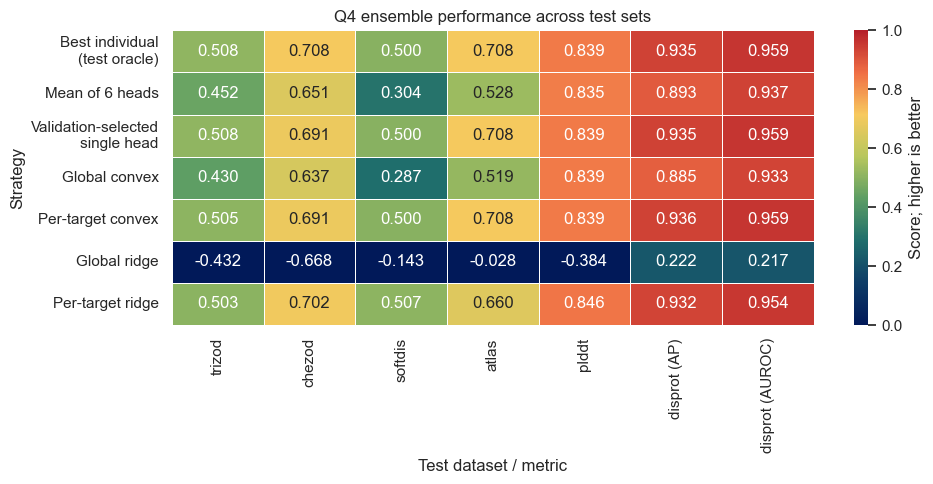

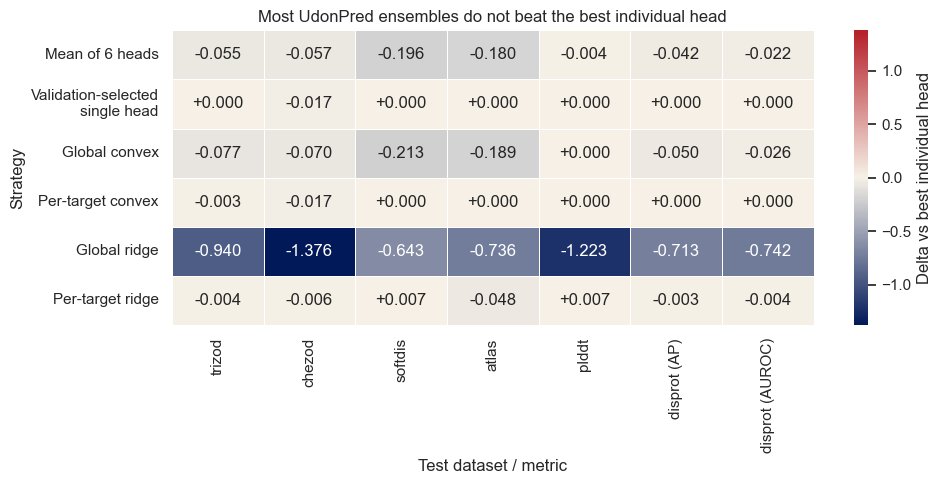

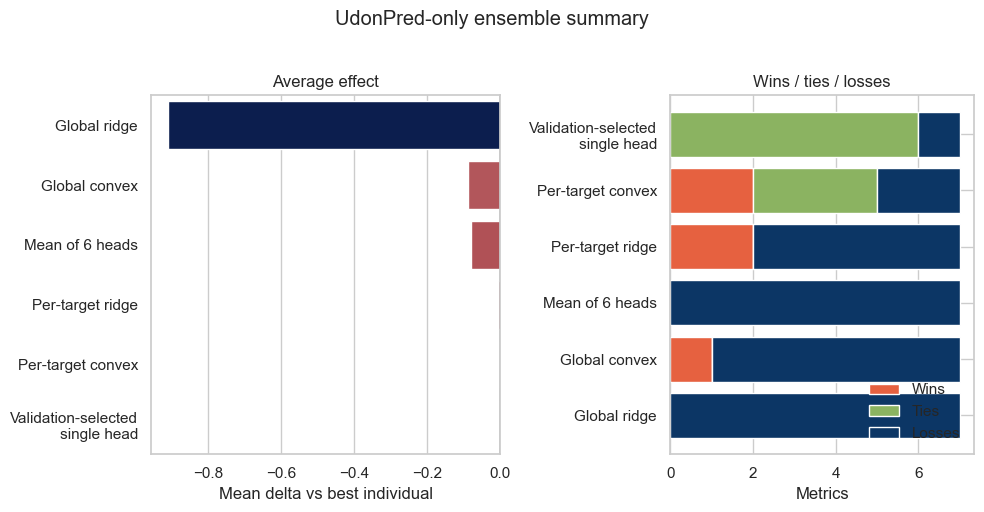

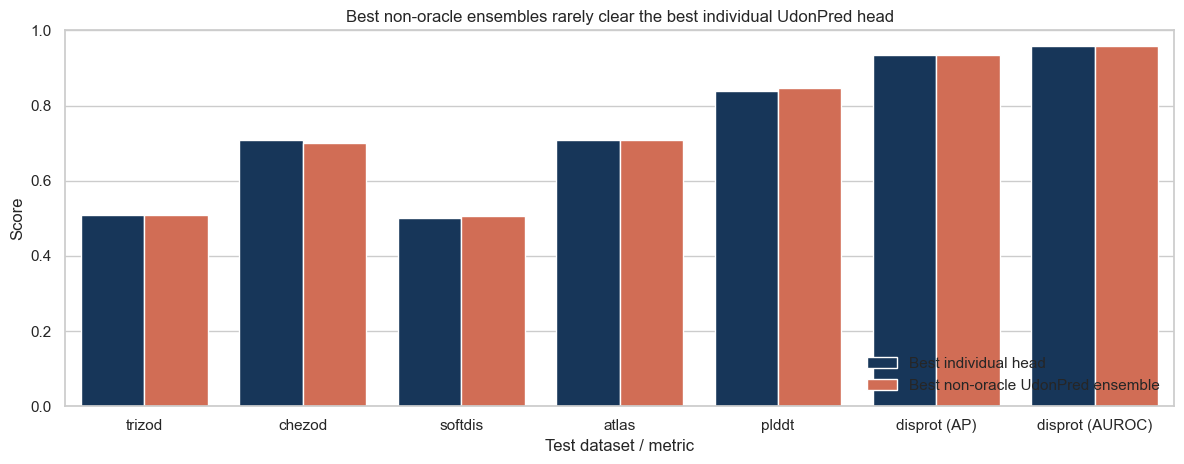

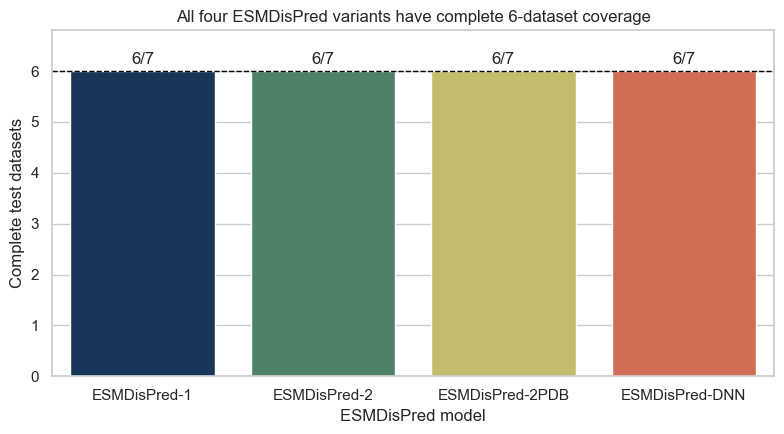

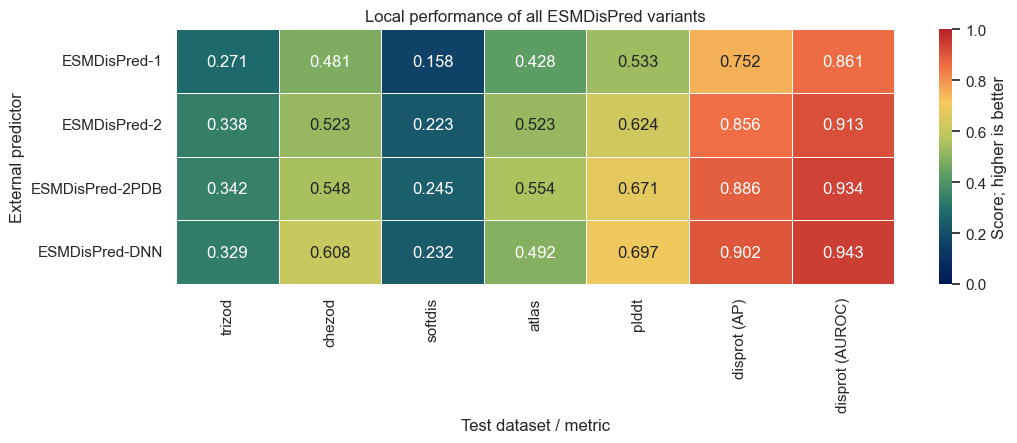

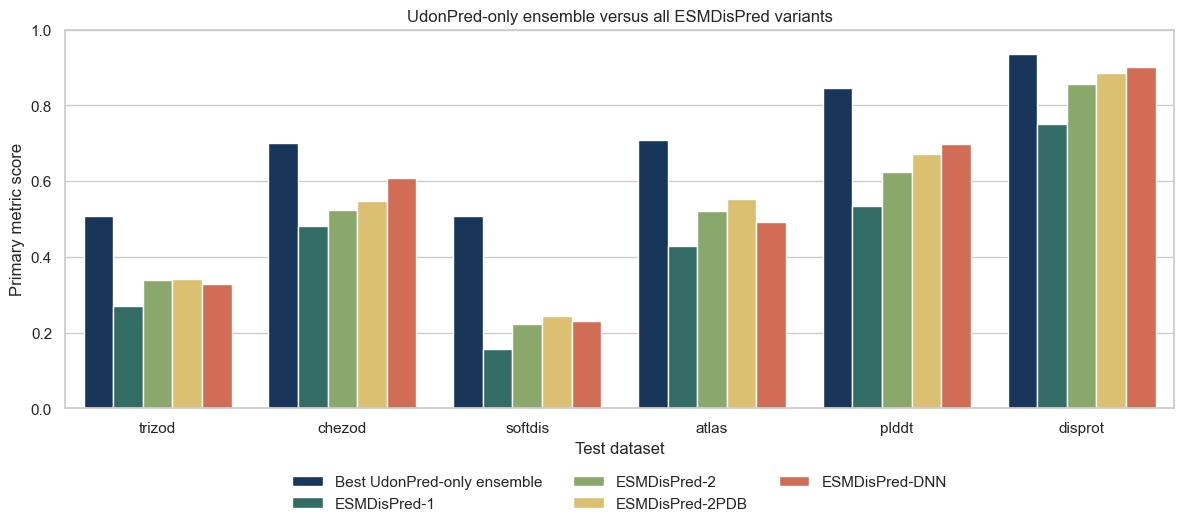

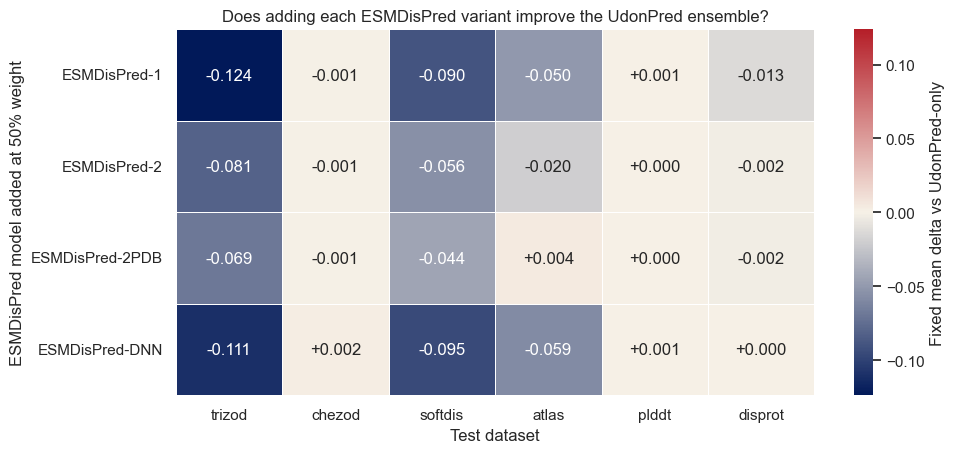

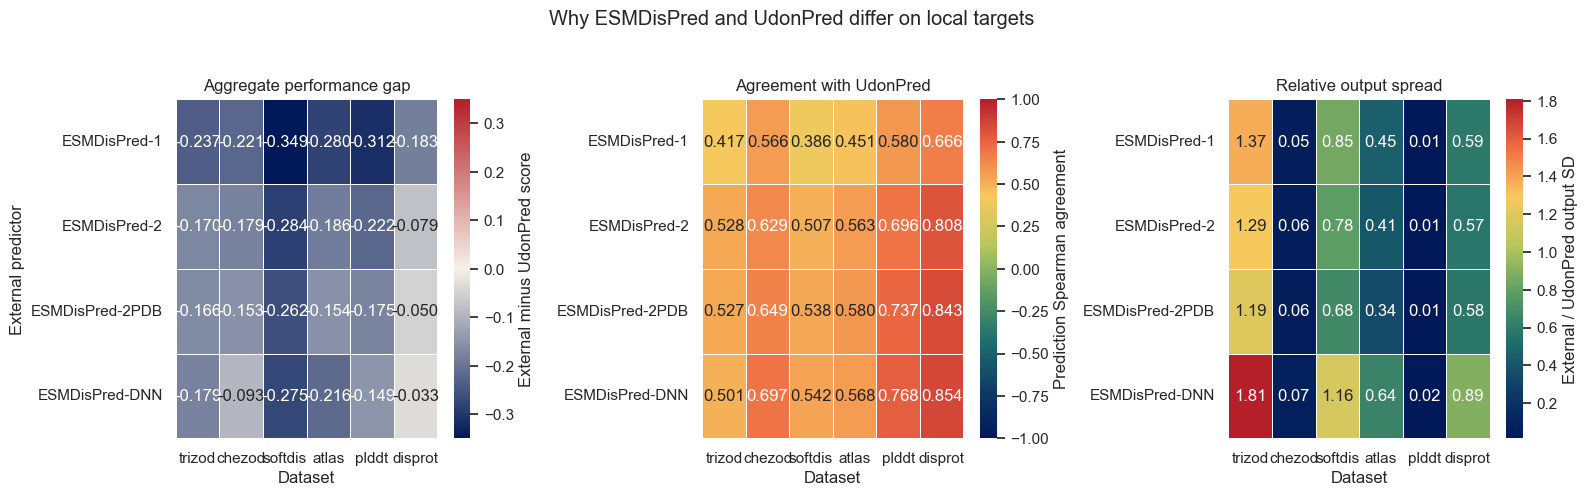

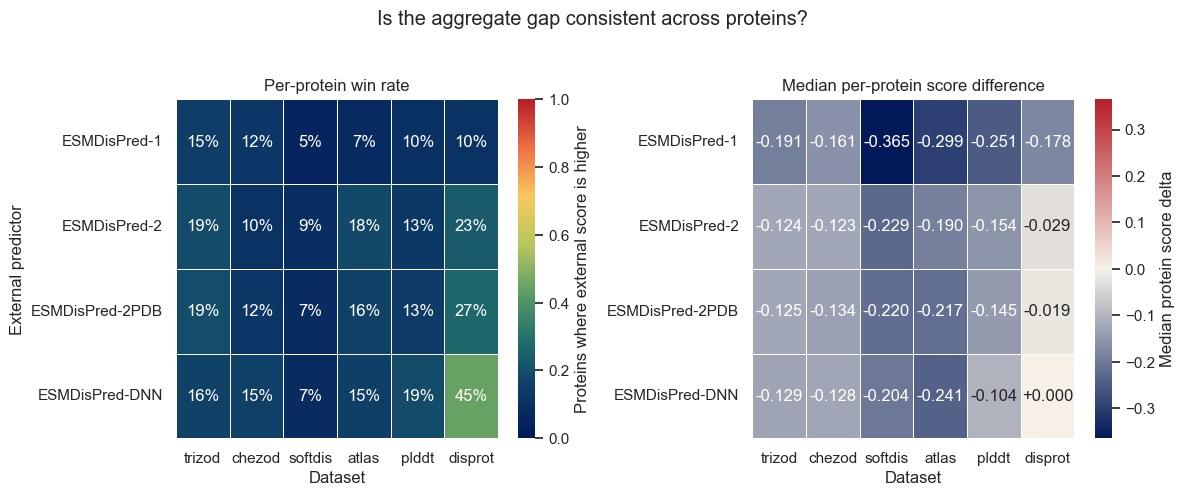

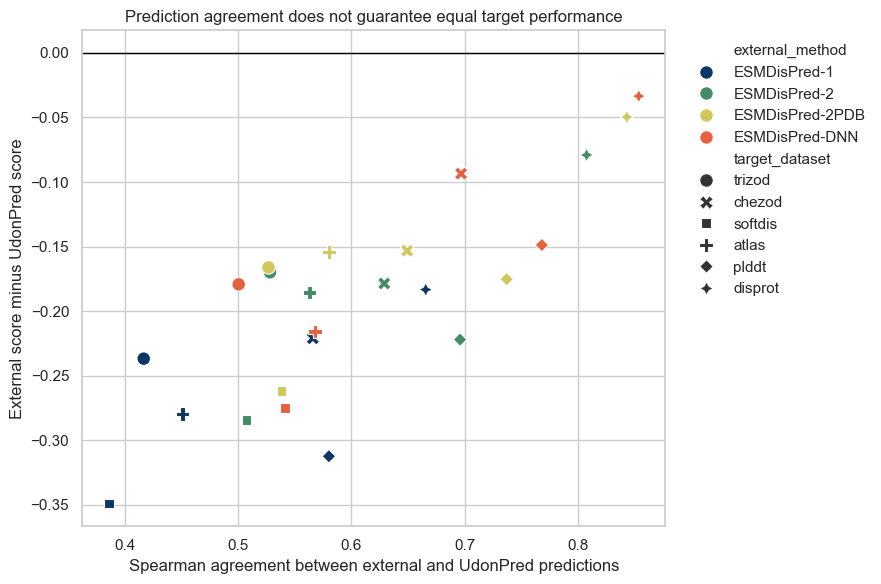

In [25]:
STRATEGY_LABELS = {
    "best_individual_test_oracle": "Best individual\n(test oracle)",
    "simple_mean_all_heads": f"Mean of {len(DATASETS)} heads",
    "validation_selected_single_head": "Validation-selected\nsingle head",
    "global_convex_validation": "Global convex",
    "per_target_convex_validation": "Per-target convex",
    "global_ridge_stacking_validation": "Global ridge",
    "per_target_ridge_stacking_validation": "Per-target ridge",
}
METRIC_LABELS = {metric: metric.replace("\n", " ") for metric in METRIC_COLS}
non_oracle_for_plots = ensemble_matrix.drop(index="best_individual_test_oracle")
best_score_by_metric_for_plots = non_oracle_for_plots.max(axis=0)


def save_current_plot(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(ENSEMBLE_DIR / filename, dpi=220, bbox_inches="tight")
    plt.show()


plot_matrix = ensemble_matrix.rename(index=STRATEGY_LABELS, columns=METRIC_LABELS)
plt.figure(figsize=(10,5))
sns.heatmap(
    plot_matrix,
    annot=True,
    fmt=".3f",
    cmap=BATLOW_CMAP,
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Score; higher is better"},
)
plt.xlabel("Test dataset / metric")
plt.ylabel("Strategy")
plt.title("Q4 ensemble performance across test sets")
save_current_plot("ensemble_matrix_heatmap.png")

plot_delta = ensemble_delta.drop(index="best_individual_test_oracle").rename(
    index=STRATEGY_LABELS,
    columns=METRIC_LABELS,
)
max_abs_delta = float(np.nanmax(np.abs(plot_delta.to_numpy())))
plt.figure(figsize=(10, 5))
sns.heatmap(
    plot_delta,
    annot=True,
    fmt="+.3f",
    cmap=BATLOW_DIVERGING_CMAP,
    center=0,
    vmin=-max_abs_delta,
    vmax=max_abs_delta,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Delta vs best individual head"},
)
plt.xlabel("Test dataset / metric")
plt.ylabel("Strategy")
plt.title("Most UdonPred ensembles do not beat the best individual head")
save_current_plot("ensemble_delta_vs_best_individual_heatmap.png")

summary_plot = ensemble_summary.drop(index="best_individual_test_oracle").reset_index()
summary_plot["strategy_label"] = summary_plot["strategy"].map(STRATEGY_LABELS)
summary_plot = summary_plot.sort_values("mean_delta_vs_best_individual")
fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={"width_ratios": [1.15, 1.0]})
sns.barplot(
    data=summary_plot,
    y="strategy_label",
    x="mean_delta_vs_best_individual",
    hue="mean_delta_vs_best_individual",
    palette=BATLOW_DIVERGING_CMAP,
    legend=False,
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlabel("Mean delta vs best individual")
axes[0].set_ylabel("")
axes[0].set_title("Average effect")

left = np.zeros(len(summary_plot))
count_palette = batlow_palette(3)
count_colors = {"wins_vs_best_individual": count_palette[2], "ties_vs_best_individual": count_palette[1], "losses_vs_best_individual": count_palette[0]}
count_labels = {"wins_vs_best_individual": "Wins", "ties_vs_best_individual": "Ties", "losses_vs_best_individual": "Losses"}
for col in ["wins_vs_best_individual", "ties_vs_best_individual", "losses_vs_best_individual"]:
    axes[1].barh(
        summary_plot["strategy_label"],
        summary_plot[col],
        left=left,
        color=count_colors[col],
        label=count_labels[col],
    )
    left = left + summary_plot[col].to_numpy()
axes[1].set_xlabel("Metrics")
axes[1].set_ylabel("")
axes[1].set_title("Wins / ties / losses")
axes[1].legend(frameon=False, loc="lower right")
fig.suptitle("UdonPred-only ensemble summary", y=1.02)
save_current_plot("ensemble_summary_delta_and_wins.png")

best_score_plot = pd.DataFrame(
    {
        "metric": METRIC_COLS,
        "Best individual head": [best_individual_scores[m] for m in METRIC_COLS],
        "Best non-oracle UdonPred ensemble": [best_score_by_metric_for_plots[m] for m in METRIC_COLS],
    }
)
best_score_long = best_score_plot.melt("metric", var_name="method", value_name="score")
best_score_long["metric"] = best_score_long["metric"].map(METRIC_LABELS)
plt.figure(figsize=(12, 4.8))
sns.barplot(
    data=best_score_long,
    x="metric",
    y="score",
    hue="method",
    palette=batlow_palette(2),
)
plt.ylim(0, 1)
plt.xlabel("Test dataset / metric")
plt.ylabel("Score")
plt.title("Best non-oracle ensembles rarely clear the best individual UdonPred head")
plt.legend(frameon=False, loc="lower right")
save_current_plot("best_individual_vs_best_ensemble_by_metric.png")

coverage = globals().get("esmdispred_coverage", pd.DataFrame())
if not coverage.empty:
    coverage_summary = (
        coverage.groupby("method", as_index=False)["complete"]
        .sum()
        .rename(columns={"complete": "complete_datasets"})
    )
    coverage_summary["complete_datasets"] = coverage_summary["complete_datasets"].astype(int)
    plt.figure(figsize=(8, 4.5))
    ax = sns.barplot(
        data=coverage_summary,
        x="method",
        y="complete_datasets",
        hue="method",
        palette=batlow_palette(coverage_summary["method"].nunique()),
        legend=False,
    )
    ax.axhline(len(DATASETS), color="black", linewidth=1, linestyle="--")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d/7", padding=3)
    plt.ylim(0, len(DATASETS) + 0.8)
    plt.xlabel("ESMDisPred model")
    plt.ylabel("Complete test datasets")
    plt.title(f"All four ESMDisPred variants have complete {len(DATASETS)}-dataset coverage")
    save_current_plot("esmdispred_local_coverage.png")

if not esmdispred_matrix.empty:
    external_matrix_plot = esmdispred_matrix.rename(columns=METRIC_LABELS)
    plt.figure(figsize=(11, 4.6))
    sns.heatmap(
        external_matrix_plot,
        annot=True,
        fmt=".3f",
        cmap=BATLOW_CMAP,
        vmin=0.0,
        vmax=1.0,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Score; higher is better"},
    )
    plt.xlabel("Test dataset / metric")
    plt.ylabel("External predictor")
    plt.title("Local performance of all ESMDisPred variants")
    save_current_plot("esmdispred_all_models_matrix_heatmap.png")

external_plot = globals().get("external_comparison", pd.DataFrame())
if not external_plot.empty:
    dataset_order = [ds for ds in DATASETS if ds in set(external_plot["target_dataset"])]

    udon_scores = (
        external_plot[["target_dataset", "best_udon_ensemble"]]
        .drop_duplicates("target_dataset")
        .rename(columns={"best_udon_ensemble": "score"})
    )
    udon_scores["method"] = "Best UdonPred-only ensemble"
    external_scores = external_plot[
        ["external_method", "target_dataset", "external_score"]
    ].rename(columns={"external_method": "method", "external_score": "score"})
    score_plot = pd.concat([udon_scores, external_scores], ignore_index=True)
    score_plot["target_dataset"] = pd.Categorical(
        score_plot["target_dataset"], categories=dataset_order, ordered=True
    )
    method_order = ["Best UdonPred-only ensemble", *ESMDISPRED_MODELS]
    plt.figure(figsize=(12, 5.5))
    sns.barplot(
        data=score_plot,
        x="target_dataset",
        y="score",
        hue="method",
        hue_order=method_order,
        palette=batlow_palette(len(method_order)),
    )
    plt.ylim(0, 1)
    plt.xlabel("Test dataset")
    plt.ylabel("Primary metric score")
    plt.title("UdonPred-only ensemble versus all ESMDisPred variants")
    plt.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    save_current_plot("external_all_models_standalone_scores.png")

    delta_matrix = external_plot.pivot(
        index="external_method",
        columns="target_dataset",
        values="delta_fixed_mean_vs_udon_ensemble",
    ).reindex(index=ESMDISPRED_MODELS, columns=dataset_order)
    max_abs_external_delta = float(np.nanmax(np.abs(delta_matrix.to_numpy())))
    plt.figure(figsize=(10, 4.7))
    sns.heatmap(
        delta_matrix,
        annot=True,
        fmt="+.3f",
        cmap=BATLOW_DIVERGING_CMAP,
        center=0,
        vmin=-max_abs_external_delta,
        vmax=max_abs_external_delta,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Fixed mean delta vs UdonPred-only"},
    )
    plt.xlabel("Test dataset")
    plt.ylabel("ESMDisPred model added at 50% weight")
    plt.title("Does adding each ESMDisPred variant improve the UdonPred ensemble?")
    save_current_plot("external_all_models_fixed_mean_delta_heatmap.png")
# Performance-gap diagnostics for UdonPred versus ESMDisPred.
if "model_diagnostics" in globals() and not model_diagnostics.empty:
    diagnostic_order = [ds for ds in DATASETS if ds in set(model_diagnostics["target_dataset"])]
    gap_matrix = model_diagnostics.pivot(
        index="external_method",
        columns="target_dataset",
        values="score_gap_external_minus_udon",
    ).reindex(index=ESMDISPRED_MODELS, columns=diagnostic_order)
    agreement_matrix = model_diagnostics.pivot(
        index="external_method",
        columns="target_dataset",
        values="prediction_agreement_spearman",
    ).reindex(index=ESMDISPRED_MODELS, columns=diagnostic_order)
    spread_matrix = model_diagnostics.pivot(
        index="external_method",
        columns="target_dataset",
        values="output_std_ratio_external_to_udon",
    ).reindex(index=ESMDISPRED_MODELS, columns=diagnostic_order)

    max_abs_gap = float(np.nanmax(np.abs(gap_matrix.to_numpy())))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    sns.heatmap(
        gap_matrix,
        annot=True,
        fmt="+.3f",
        cmap=BATLOW_DIVERGING_CMAP,
        center=0,
        vmin=-max_abs_gap,
        vmax=max_abs_gap,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "External minus UdonPred score"},
        ax=axes[0],
    )
    axes[0].set_title("Aggregate performance gap")
    axes[0].set_xlabel("Dataset")
    axes[0].set_ylabel("External predictor")

    sns.heatmap(
        agreement_matrix,
        annot=True,
        fmt=".3f",
        cmap=BATLOW_CMAP,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Prediction Spearman agreement"},
        ax=axes[1],
    )
    axes[1].set_title("Agreement with UdonPred")
    axes[1].set_xlabel("Dataset")
    axes[1].set_ylabel("")

    sns.heatmap(
        spread_matrix,
        annot=True,
        fmt=".2f",
        cmap=BATLOW_CMAP,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "External / UdonPred output SD"},
        ax=axes[2],
    )
    axes[2].set_title("Relative output spread")
    axes[2].set_xlabel("Dataset")
    axes[2].set_ylabel("")
    fig.suptitle("Why ESMDisPred and UdonPred differ on local targets", y=1.03)
    save_current_plot("external_performance_gap_agreement_spread.png")

    protein_win_matrix = model_diagnostics.pivot(
        index="external_method",
        columns="target_dataset",
        values="external_protein_win_rate",
    ).reindex(index=ESMDISPRED_MODELS, columns=diagnostic_order)
    protein_delta_matrix = model_diagnostics.pivot(
        index="external_method",
        columns="target_dataset",
        values="median_external_protein_delta",
    ).reindex(index=ESMDISPRED_MODELS, columns=diagnostic_order)
    max_abs_protein_delta = float(np.nanmax(np.abs(protein_delta_matrix.to_numpy())))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    sns.heatmap(
        protein_win_matrix,
        annot=True,
        fmt=".0%",
        cmap=BATLOW_CMAP,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Proteins where external score is higher"},
        ax=axes[0],
    )
    axes[0].set_title("Per-protein win rate")
    axes[0].set_xlabel("Dataset")
    axes[0].set_ylabel("External predictor")

    sns.heatmap(
        protein_delta_matrix,
        annot=True,
        fmt="+.3f",
        cmap=BATLOW_DIVERGING_CMAP,
        center=0,
        vmin=-max_abs_protein_delta,
        vmax=max_abs_protein_delta,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Median protein score delta"},
        ax=axes[1],
    )
    axes[1].set_title("Median per-protein score difference")
    axes[1].set_xlabel("Dataset")
    axes[1].set_ylabel("")
    fig.suptitle("Is the aggregate gap consistent across proteins?", y=1.03)
    save_current_plot("external_per_protein_win_rate_and_delta.png")

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=model_diagnostics,
        x="prediction_agreement_spearman",
        y="score_gap_external_minus_udon",
        hue="external_method",
        style="target_dataset",
        palette=batlow_palette(model_diagnostics["external_method"].nunique()),
        s=95,
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("Spearman agreement between external and UdonPred predictions")
    plt.ylabel("External score minus UdonPred score")
    plt.title("Prediction agreement does not guarantee equal target performance")
    plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    save_current_plot("external_agreement_vs_performance_gap.png")


## 12. Q4 Interpretation

In [26]:
non_oracle = ensemble_matrix.drop(index="best_individual_test_oracle")
best_strategy_by_metric = non_oracle.idxmax(axis=0)
best_score_by_metric = non_oracle.max(axis=0)

q4_summary = ensemble_summary.drop(index="best_individual_test_oracle").copy()
display(q4_summary.style.format({
    "mean_score": "{:.3f}",
    "mean_delta_vs_best_individual": "{:+.3f}",
    "best_delta": "{:+.3f}",
    "worst_delta": "{:+.3f}",
}))

print("Best non-oracle UdonPred strategy per metric:")
for metric in METRIC_COLS:
    print(f"- {metric}: {best_strategy_by_metric[metric]} ({best_score_by_metric[metric]:.3f}); "
          f"best individual {best_individual_scores[metric]:.3f} from {best_individual_heads[metric]}")

print()
print("Single global UdonPred ensemble generalization:")
for row in ["global_convex_validation", "global_ridge_stacking_validation"]:
    stats = ensemble_summary.loc[row]
    print(
        f"- {row}: mean delta {stats['mean_delta_vs_best_individual']:.3f}, "
        f"wins {int(stats['wins_vs_best_individual'])}/{len(METRIC_COLS)}, "
        f"worst delta {stats['worst_delta']:.3f}."
    )

print()
if not esmdispred_matrix.empty:
    print("Complete local ESMDisPred scores on the same UdonPred test sets:")
    display(esmdispred_matrix.style.format("{:.3f}"))
else:
    print(f"No complete {len(DATASETS)}-dataset local ESMDisPred score matrix is available.")

coverage = globals().get("esmdispred_coverage", pd.DataFrame())
if not coverage.empty:
    complete_counts = coverage.groupby("method")["complete"].sum().astype(int)
    print("Local ESMDisPred completed datasets by model:")
    for method in ESMDISPRED_MODELS:
        print(f"- {method}: {complete_counts.get(method, 0)}/{len(DATASETS)}")

external_table = globals().get("external_comparison", pd.DataFrame())
if not external_table.empty:
    external_summary = (
        external_table.groupby("external_method")
        .agg(
            datasets=("target_dataset", "count"),
            mean_external_score=("external_score", "mean"),
            mean_fixed_mean_delta=("delta_fixed_mean_vs_udon_ensemble", "mean"),
            wins_vs_udon=("delta_fixed_mean_vs_udon_ensemble", lambda x: int((x > 1e-6).sum())),
        )
        .reindex(ESMDISPRED_MODELS)
    )
    print()
    print("Fixed 50/50 UdonPred + external predictor summary:")
    display(external_summary.style.format({
        "mean_external_score": "{:.3f}",
        "mean_fixed_mean_delta": "{:+.3f}",
    }))
    for method, stats in external_summary.iterrows():
        print(
            f"- {method}: fixed mean wins on {int(stats['wins_vs_udon'])}/{int(stats['datasets'])} datasets; "
            f"mean delta {stats['mean_fixed_mean_delta']:+.3f}."
        )

diagnostic_table = globals().get("model_diagnostics", pd.DataFrame())
if not diagnostic_table.empty:
    method_diagnostic_summary = diagnostic_table.groupby("external_method").agg(
        mean_score_gap=("score_gap_external_minus_udon", "mean"),
        mean_prediction_agreement=("prediction_agreement_spearman", "mean"),
        mean_protein_win_rate=("external_protein_win_rate", "mean"),
        mean_output_std_ratio=("output_std_ratio_external_to_udon", "mean"),
    ).reindex(ESMDISPRED_MODELS)
    dataset_gap_summary = diagnostic_table.groupby("target_dataset")[
        "score_gap_external_minus_udon"
    ].mean().sort_values()
    agreement_gap_association = safe_spearman(
        diagnostic_table["prediction_agreement_spearman"].to_numpy(),
        diagnostic_table["score_gap_external_minus_udon"].to_numpy(),
    )
    print()
    print("Performance-gap diagnostics:")
    display(method_diagnostic_summary.style.format({
        "mean_score_gap": "{:+.3f}",
        "mean_prediction_agreement": "{:.3f}",
        "mean_protein_win_rate": "{:.1%}",
        "mean_output_std_ratio": "{:.2f}",
    }))
    print(
        f"- Largest average external deficit: {dataset_gap_summary.index[0]} "
        f"({dataset_gap_summary.iloc[0]:+.3f})."
    )
    print(
        f"- Smallest average external deficit: {dataset_gap_summary.index[-1]} "
        f"({dataset_gap_summary.iloc[-1]:+.3f})."
    )
    print(
        f"- Across the 28 model-dataset pairs, prediction agreement versus score gap has "
        f"Spearman correlation {agreement_gap_association:.3f}."
    )

print()
print("Q4 conclusion:")
print("- UdonPred-only predictions were evaluated with simple averaging, validation-selected heads, convex weighting, and ridge stacking.")
print("- The saved UdonPred ensembles mostly do not outperform the best individual UdonPred head.")
print("- Per-target ensembles help selected datasets, but a single global UdonPred ensemble generalizes poorly.")
if len(esmdispred_matrix.index) == len(ESMDISPRED_MODELS):
    print(f"- All four ESMDisPred variants are complete on all {len(DATASETS)} retained local test sets and are directly compared using the same labels and metrics.")
if not external_table.empty:
    total_wins = int((external_table["delta_fixed_mean_vs_udon_ensemble"] > 1e-6).sum())
    print(f"- Across all fixed 50/50 external combinations, adding an ESMDisPred model improves {total_wins}/{len(external_table)} model-dataset comparisons.")
    print("- These are fixed-weight diagnostics, not learned external stacking, because ESMDisPred validation predictions were not used to fit weights.")
if not diagnostic_table.empty:
    print("- The added agreement and per-protein analyses distinguish broad target mismatch from isolated aggregate-score effects; inspect the diagnostic heatmaps rather than interpreting CAID rank as universal across these target definitions.")


,mean_score,mean_delta_vs_best_individual,wins_vs_best_individual,ties_vs_best_individual,losses_vs_best_individual,best_delta,worst_delta
strategy,,,,,,,
simple_mean_all_heads,0.657,-0.080,0,0,7,-0.004,-0.196
validation_selected_single_head,0.734,-0.002,0,6,1,+0.000,-0.017
global_convex_validation,0.647,-0.090,1,0,6,+0.000,-0.213
per_target_convex_validation,0.734,-0.003,2,3,2,+0.000,-0.017
global_ridge_stacking_validation,-0.174,-0.911,0,0,7,-0.643,-1.376
per_target_ridge_stacking_validation,0.729,-0.007,2,0,5,+0.007,-0.048


Best non-oracle UdonPred strategy per metric:
- trizod: validation_selected_single_head (0.508); best individual 0.508 from trizod
- chezod: per_target_ridge_stacking_validation (0.702); best individual 0.708 from trizod
- softdis: per_target_ridge_stacking_validation (0.507); best individual 0.500 from softdis
- atlas: validation_selected_single_head (0.708); best individual 0.708 from atlas
- plddt: per_target_ridge_stacking_validation (0.846); best individual 0.839 from plddt
- disprot
(AP): per_target_convex_validation (0.936); best individual 0.935 from disprot
- disprot
(AUROC): per_target_convex_validation (0.959); best individual 0.959 from disprot

Single global UdonPred ensemble generalization:
- global_convex_validation: mean delta -0.090, wins 1/7, worst delta -0.213.
- global_ridge_stacking_validation: mean delta -0.911, wins 0/7, worst delta -1.376.

Complete local ESMDisPred scores on the same UdonPred test sets:


,trizod,chezod,softdis,atlas,plddt,disprot (AP),disprot (AUROC)
method,,,,,,,
ESMDisPred-1,0.271,0.481,0.158,0.428,0.533,0.752,0.861
ESMDisPred-2,0.338,0.523,0.223,0.523,0.624,0.856,0.913
ESMDisPred-2PDB,0.342,0.548,0.245,0.554,0.671,0.886,0.934
ESMDisPred-DNN,0.329,0.608,0.232,0.492,0.697,0.902,0.943


Local ESMDisPred completed datasets by model:
- ESMDisPred-1: 6/6
- ESMDisPred-2: 6/6
- ESMDisPred-2PDB: 6/6
- ESMDisPred-DNN: 6/6

Fixed 50/50 UdonPred + external predictor summary:


,datasets,mean_external_score,mean_fixed_mean_delta,wins_vs_udon
external_method,,,,
ESMDisPred-1,6,0.437,-0.046,1
ESMDisPred-2,6,0.514,-0.027,1
ESMDisPred-2PDB,6,0.541,-0.018,2
ESMDisPred-DNN,6,0.543,-0.044,3


- ESMDisPred-1: fixed mean wins on 1/6 datasets; mean delta -0.046.
- ESMDisPred-2: fixed mean wins on 1/6 datasets; mean delta -0.027.
- ESMDisPred-2PDB: fixed mean wins on 2/6 datasets; mean delta -0.018.
- ESMDisPred-DNN: fixed mean wins on 3/6 datasets; mean delta -0.044.

Performance-gap diagnostics:


,mean_score_gap,mean_prediction_agreement,mean_protein_win_rate,mean_output_std_ratio
external_method,,,,
ESMDisPred-1,-0.264,0.511,9.9%,0.55
ESMDisPred-2,-0.187,0.622,15.3%,0.52
ESMDisPred-2PDB,-0.160,0.646,15.8%,0.48
ESMDisPred-DNN,-0.158,0.655,19.6%,0.76


- Largest average external deficit: softdis (-0.293).
- Smallest average external deficit: disprot (-0.086).
- Across the 28 model-dataset pairs, prediction agreement versus score gap has Spearman correlation 0.720.

Q4 conclusion:
- UdonPred-only predictions were evaluated with simple averaging, validation-selected heads, convex weighting, and ridge stacking.
- The saved UdonPred ensembles mostly do not outperform the best individual UdonPred head.
- Per-target ensembles help selected datasets, but a single global UdonPred ensemble generalizes poorly.
- All four ESMDisPred variants are complete on all 6 retained local test sets and are directly compared using the same labels and metrics.
- Across all fixed 50/50 external combinations, adding an ESMDisPred model improves 7/24 model-dataset comparisons.
- These are fixed-weight diagnostics, not learned external stacking, because ESMDisPred validation predictions were not used to fit weights.
- The added agreement and per-protein analyse